# Комбинации (concat) mean-pooling с другими пулингами. Базовый энкодер.

## Цель эксперимента

Убедиться в том, что комбинации пулингов могут иметь метрику выше, чем каждый по отдельности.

## Проверяемые предположения

1. При конкатенации эмбеддингов, полученных использованием различных пуллингов, возможен рост метрик.
2. Центрирование по среднему.
```
Если эмбеддинг из первого пула (mean-pooling) отражает в основном семантику, а второй содержит и семантику, и структурную информацию, то можно попытаться выделить "чистую структуру", вычитая из второго первый. Тогда, если сконкатенировать mean-представление с этой разностью, метрика может улучшиться.

Иными словами, конструкция
concat(mean-pooling, diff-pooling − mean-pooling)
теоретически должна давать более высокий ROC-AUC, чем простая
concat(mean-pooling, diff-pooling),
поскольку во втором случае информация частично дублируется, а в первом — компоненты становятся более независимыми.
```
3. Нормализация эмбеддингов может повысить ROC-AUC, поскольку вектора, полученные разными способами пуллинга, способны иметь существенно различающиеся масштабы. Приведение их к единому масштабу уменьшает перекос отдельных компонент и делает сравнение более корректным. 

### Методы
1. Isolation Forest. Количество разрезов для изоляции.
2. Autoencoder. Учится хорошо восстанавливать нормальные данные.

Выбор методов обусловлен их высокой вычислительной эффективностью при большом объеме расчетов и высокой размерности векторов. В предыдущих экспериментах Autoencoder продемонстрировал наилучшие показатели, а оценки Isolation Forest оказались с ним хорошо согласованными.

### Энкодеры
Один - самый быстрый: `all-MiniLM-L6-v2`.

### Эмбеддинги

В эксперименте рассматриваются различные способы агрегации эмбеддингов предложений в вектор документа. Каждый документ представлен как последовательность векторов предложений, полученных с помощью энкодера.

1. Базовые:
    1. **Mean-pooling**. Покомпонентное усреднение эмбеддингов всех предложений документа. Дает устойчивое обобщённое семантическое представление. Выбран в качестве бейзлайна.
    2. **Max-pooling**. Покомпонентный максимум по эмбеддингам предложений. Позволяет выделить наиболее выраженные признаки среди всех предложений.
    3. **Var-pooling**. Покомпонентная дисперсия эмбеддингов предложений. Характеризует вариативность содержания документа.
    4. **Median-pooling**. Покомпонентная медиана по предложениям. Более устойчив к выбросам и аномальным предложениям.
2. Структура без порядка предложений:
    1. **Mean-diff-pooling**. Средняя разниц между эмбеддингами соседних предложений.
    2. **Max-diff-pooling**. Покомпонентный максимум разниц между эмбеддингами соседних предложений.
    3. **Min-diff-pooling**. Покомпонентный минимум разниц между эмбеддингами соседних предложений.
    4. **Median-diff-pooling**. Покомпонентная медиана разниц между эмбеддингами соседних предложений.
    5. **Var-diff-pooling**. Покомпонентная дисперсия разниц между эмбеддингами соседних предложений.
3. Структура порядком предложений (по аналогии с механизмом внимания):
    1. **DWP-pooling** (Distance Weighted Pooling). Взвешенная сумма эмбеддингов предложений. Веса зависят от "расстояния" между эмбеддингом предложения и средним эмбеддингом (из mean-pooling).

### Методика

Mean-pooling используется в качестве базового.
Далее его эмбеддинг поочерёдно конкатенируется с векторами, полученными с помощью других методов пуллинга.
Для каждой такой комбинации вычисляется максимальное значение ROC-AUC при различных значениях коэффициента масштабирования t.

Дополнительно рассматриваются варианты с центрированием эмбеддингов (вычитанием среднего) и их нормализацией.

In [1]:
ENCODERS = [
    "sentence-transformers/all-MiniLM-L6-v2",
]

KNN_N_NEIGHBORS = 5
LOF_N_NEIGHBORS = 20
ENCODE_BATCH_SIZE = 64
AE_EPOCH_N = 30

device = "mps"

In [2]:
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, average_precision_score, auc
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import re
import random
from tqdm import tqdm
from itertools import product
from collections import defaultdict

import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/artfultom/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [4]:
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["TOKENIZERS_PARALLELISM"] = "false"

### Данные
- TRAIN: Живые эссе с Ivy Panda, 90805 штук.
- TEST: Живые эссе с Ivy Panda + сгенерированные (Mistral 7B, Llama 3 13B, ChatGPT, DeepSeek). Пропорции 50/50. Суммарно 74976 штук.

In [5]:
filenames = [
    "../datasets/mistral_essays_1.csv",
    "../datasets/mistral_essays_2.csv",
    "../datasets/mistral_essays_3.csv",
    "../datasets/mistral_essays_4.csv",
    "../datasets/mistral_essays_5.csv",
    "../datasets/llama_essays_1.csv",
    "../datasets/llama_essays_2.csv",
    "../datasets/llama_essays_3.csv",
    "../datasets/llama_essays_4.csv",
    "../datasets/llama_essays_5.csv",
    "../datasets/deepseek_essays_1.csv",
    "../datasets/deepseek_essays_2.csv",
    "../datasets/deepseek_essays_3.csv",
    "../datasets/deepseek_essays_4.csv",
    "../datasets/deepseek_essays_5.csv",
    "../datasets/chatgpt_essays_1.csv",
    "../datasets/chatgpt_essays_2.csv",
    "../datasets/chatgpt_essays_3.csv",
    "../datasets/chatgpt_essays_4.csv",
    "../datasets/chatgpt_essays_5.csv",
]
df_ai = pd.concat([pd.read_csv(f) for f in filenames], ignore_index=True).assign(label=1)[["text", "label"]]#.sample(n=200, random_state=SEED)

df_human = pd.read_csv("../datasets/ivy_panda_essays.csv").assign(label=0)[["text", "label"]].reset_index(drop=True)#.sample(n=400, random_state=SEED)
df_train, df_human_test = train_test_split(df_human, test_size=len(df_ai), random_state=SEED)

df_all = pd.concat([df_ai, df_human_test], ignore_index=True).sample(frac=1, random_state=SEED)

In [6]:
print(f"Загружено {len(df_train)} записей Ivy Panda (живые, train)")
print(f"Загружено {len(df_all)} записей (синтетика + живые, test)")

Загружено 90805 записей Ivy Panda (живые, train)
Загружено 74976 записей (синтетика + живые, test)


In [7]:
class AE(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(dim, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU(),
        )
        self.dec = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, dim),
        )
    def forward(self, x):
        return self.dec(self.enc(x))

In [14]:
def plot_grouped_by_index(results):
    for model_name, data in results.items():
        print(f"Модель: {model_name}")
        for index, models_data in data.items():
            plt.figure(figsize=(8, 4))
    
            colors = plt.cm.tab10.colors
            color_i = 0
    
            for model_key, t_data in models_data.items():
                t_vals = sorted(t_data.keys())
    
                roc_vals = [
                    max(
                        roc_auc_score(t_data[v]["IF"][1], t_data[v]["IF"][0]),
                        roc_auc_score(t_data[v]["AE"][1], t_data[v]["AE"][0]),
                    )
                    for v in t_vals
                ]
    
                color = colors[color_i % len(colors)]
                color_i += 1
    
                plt.plot(t_vals, roc_vals, marker="o", linewidth=2, markersize=5, color=color, label=model_key)
    
                max_i = np.argmax(roc_vals)
                plt.scatter(t_vals[max_i], roc_vals[max_i], color="crimson", s=60, zorder=5)
    
            plt.xlabel(f"t[{index}]", fontsize=11)
            plt.ylabel("Max ROC-AUC", fontsize=11)
            plt.title(f"ROC-AUC vs t · index={index}", fontsize=12, pad=10)
    
            plt.grid(True, linestyle="--", alpha=0.4)
            plt.legend(frameon=False, fontsize=8)
    
            plt.tight_layout()
            plt.show()

In [9]:
def eval_scores(name, scores, y):
    auc = roc_auc_score(y, scores)
    ap = average_precision_score(y, scores)
    print(f"{name:20s} | ROC-AUC: {auc:.4f} | PR-AUC: {ap:.4f}")

In [10]:
def normalize_f(data):
    data = torch.from_numpy(data).float()
    data = F.normalize(data, p=2, dim=0)
    return data.numpy()

def dwp_pooling_diag_far(X, eps=1e-8):
    mu = X.mean(axis=0)
    var = X.var(axis=0) + eps
    dists = np.sqrt(((X - mu) ** 2 / var).sum(axis=1))
    
    weights = np.exp(dists)
    weights /= weights.sum() + eps

    return weights @ X

def get_raw_embeddings(model, data, normalize_embeddings=False):
    all_sentences = []
    spans = []

    for text in tqdm(data):
        text = re.sub(r"\n+", ". ", text)
        sentences = nltk.sent_tokenize(text)

        start = len(all_sentences)
        all_sentences.extend(sentences)
        end = len(all_sentences)

        spans.append((start, end))

    all_embeddings = model.encode(
        all_sentences,
        batch_size=ENCODE_BATCH_SIZE,
        normalize_embeddings=normalize_embeddings,
        show_progress_bar=True,
        device=device,
    )

    return spans, all_embeddings

def get_embeddings(spans, all_embeddings, centered=False, norm=False):
    mean_vals = []
    
    max_vals = []
    var_vals = []
    med_vals = []

    min_diff_vals = []
    mean_diff_vals = []
    max_diff_vals = []
    med_diff_vals = []
    var_diff_vals = []

    dwp_vals = []

    for start, end in tqdm(spans):
        embeddings = all_embeddings[start:end]

        mean_val = np.mean(embeddings, axis=0)

        if centered:
            embeddings = embeddings - mean_val

        max_val = np.max(embeddings, axis=0)
        var_val = np.var(embeddings, axis=0)
        med_val = np.median(embeddings, axis=0)

        diffs = embeddings[1:] - embeddings[:-1]
        min_diff_val = np.min(diffs, axis=0)
        mean_diff_val = np.mean(diffs, axis=0)
        max_diff_val = np.max(diffs, axis=0)
        med_diff_val = np.median(diffs, axis=0)
        var_diff_val = np.var(diffs, axis=0)

        dwp_val = dwp_pooling_diag_far(embeddings)

        mean_vals.append(mean_val)

        if norm:
            max_val = normalize_f(max_val)
            var_val = normalize_f(var_val)
            med_val = normalize_f(med_val)

            min_diff_val = normalize_f(min_diff_val)
            mean_diff_val = normalize_f(mean_diff_val)
            max_diff_val = normalize_f(max_diff_val)
            med_diff_val = normalize_f(med_diff_val)
            var_diff_val = normalize_f(var_diff_val)

            dwp_val = normalize_f(dwp_val)

        max_vals.append(max_val)
        var_vals.append(var_val)
        med_vals.append(med_val)

        min_diff_vals.append(min_diff_val)
        mean_diff_vals.append(mean_diff_val)
        max_diff_vals.append(max_diff_val)
        med_diff_vals.append(med_diff_val)
        var_diff_vals.append(var_diff_val)

        dwp_vals.append(dwp_val)

    return (
        mean_vals,
        
        max_vals,
        var_vals,
        med_vals,
        
        mean_diff_vals,
        max_diff_vals,
        min_diff_vals,
        med_diff_vals,
        var_diff_vals,
        
        dwp_vals,
    )

In [11]:
def isolation_forest_score(X_train, X_test):
    iso = IsolationForest(
        contamination='auto',
        n_estimators=200,
        random_state=SEED,
        n_jobs=-1
    )
    iso.fit(X_train)
    return -iso.decision_function(X_test)

def ae_score(X_train, X_test):
    d = X_train.shape[1]
    
    ae = AE(d).to(device)
    opt = torch.optim.Adam(ae.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    
    Xtr = torch.tensor(X_train, dtype=torch.float32).to(device)
    for epoch in range(AE_EPOCH_N):
        idx = torch.randperm(Xtr.shape[0])
        batch = Xtr[idx][:256]
        out = ae(batch)
        loss = loss_fn(out, batch)
        opt.zero_grad()
        loss.backward()
        opt.step()
    
    Xe = torch.tensor(X_test, dtype=torch.float32).to(device)
    with torch.no_grad():
        recon = ae(Xe).cpu().numpy()
    return np.mean((X_test - recon) ** 2, axis=1)

In [12]:
t_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.2, 1.4, 1.6, 1.8, 2]

results = defaultdict(lambda: defaultdict(lambda: defaultdict(dict)))

for model_name in ENCODERS:
    model = SentenceTransformer(model_name)
    print(f"\n=== Рассчет модели {model_name} ===")

    spans_train, all_embeddings_train = get_raw_embeddings(model, df_train['text'].tolist(), True)
    spans_test, all_embeddings_test = get_raw_embeddings(model, df_all['text'].tolist(), True)

    for centered in [False, True]:
        for norm in [False, True]:
            print(f"Параметры: centered={centered}, norm={norm}")
        
            train_embeddings = list(get_embeddings(spans_train, all_embeddings_train, centered=centered, norm=norm))
            test_embeddings = list(get_embeddings(spans_test, all_embeddings_test, centered=centered, norm=norm))
        
            c = len(train_embeddings)
            for index in range(1, c):    
                for v in t_values:
                    X_train = np.array(train_embeddings[0])
                    X_test = np.array(test_embeddings[0])
        
                    X_train = np.concatenate([X_train, np.array(train_embeddings[index]) * v], axis=1)
                    X_test = np.concatenate([X_test, np.array(test_embeddings[index]) * v], axis=1)
                    y_test = df_all['label'].values.astype(int)

                    # 1. Isolation Forest
                    iso_scores = isolation_forest_score(X_train, X_test)
                    
                    # 2. Autoencoder (MLP)
                    ae_scores = ae_score(X_train, X_test)

                    scores = {
                        "IF": iso_scores,
                        "AE": ae_scores
                    }
            
                    params = f"centered:{centered}, norm:{norm}"

                    results[model_name][index][params][v] = {
                        "IF": [iso_scores, y_test],
                        "AE": [ae_scores, y_test],
                    }
                print(f"Модель {model_name}, centered={centered}, norm={norm}, index={index} - DONE")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== Рассчет модели sentence-transformers/all-MiniLM-L6-v2 ===


100%|██████████████████████████████████████████████████████████████████████████| 90805/90805 [01:05<00:00, 1383.58it/s]


Batches:   0%|          | 0/114306 [00:00<?, ?it/s]

...

Модель sentence-transformers/all-MiniLM-L6-v2, centered=False, norm=True, index=1 - DONE
Модель sentence-transformers/all-MiniLM-L6-v2, centered=False, norm=True, index=2 - DONE
Модель sentence-transformers/all-MiniLM-L6-v2, centered=False, norm=True, index=3 - DONE
Модель sentence-transformers/all-MiniLM-L6-v2, centered=False, norm=True, index=4 - DONE
Модель sentence-transformers/all-MiniLM-L6-v2, centered=False, norm=True, index=5 - DONE
Модель sentence-transformers/all-MiniLM-L6-v2, centered=False, norm=True, index=6 - DONE
Модель sentence-transformers/all-MiniLM-L6-v2, centered=False, norm=True, index=7 - DONE
Модель sentence-transformers/all-MiniLM-L6-v2, centered=False, norm=True, index=8 - DONE
Модель sentence-transformers/all-MiniLM-L6-v2, centered=False, norm=True, index=9 - DONE
Параметры: centered=True, norm=False


100%|██████████████████████████████████████████████████████████████████████████| 74976/74976 [00:47<00:00, 1568.79it/s]


Модель sentence-transformers/all-MiniLM-L6-v2, centered=True, norm=False, index=1 - DONE
Модель sentence-transformers/all-MiniLM-L6-v2, centered=True, norm=False, index=2 - DONE
Модель sentence-transformers/all-MiniLM-L6-v2, centered=True, norm=False, index=3 - DONE
Модель sentence-transformers/all-MiniLM-L6-v2, centered=True, norm=False, index=4 - DONE
Модель sentence-transformers/all-MiniLM-L6-v2, centered=True, norm=False, index=5 - DONE
Модель sentence-transformers/all-MiniLM-L6-v2, centered=True, norm=False, index=6 - DONE
Модель sentence-transformers/all-MiniLM-L6-v2, centered=True, norm=False, index=7 - DONE
Модель sentence-transformers/all-MiniLM-L6-v2, centered=True, norm=False, index=8 - DONE
Модель sentence-transformers/all-MiniLM-L6-v2, centered=True, norm=False, index=9 - DONE
Параметры: centered=True, norm=True


100%|██████████████████████████████████████████████████████████████████████████| 74976/74976 [00:53<00:00, 1411.55it/s]


Модель sentence-transformers/all-MiniLM-L6-v2, centered=True, norm=True, index=1 - DONE
Модель sentence-transformers/all-MiniLM-L6-v2, centered=True, norm=True, index=2 - DONE
Модель sentence-transformers/all-MiniLM-L6-v2, centered=True, norm=True, index=3 - DONE
Модель sentence-transformers/all-MiniLM-L6-v2, centered=True, norm=True, index=4 - DONE
Модель sentence-transformers/all-MiniLM-L6-v2, centered=True, norm=True, index=5 - DONE
Модель sentence-transformers/all-MiniLM-L6-v2, centered=True, norm=True, index=6 - DONE
Модель sentence-transformers/all-MiniLM-L6-v2, centered=True, norm=True, index=7 - DONE
Модель sentence-transformers/all-MiniLM-L6-v2, centered=True, norm=True, index=8 - DONE
Модель sentence-transformers/all-MiniLM-L6-v2, centered=True, norm=True, index=9 - DONE


## Результаты

Модель: sentence-transformers/all-MiniLM-L6-v2


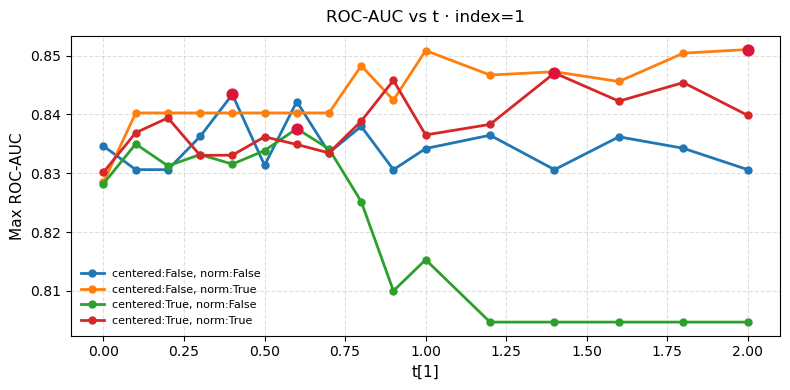

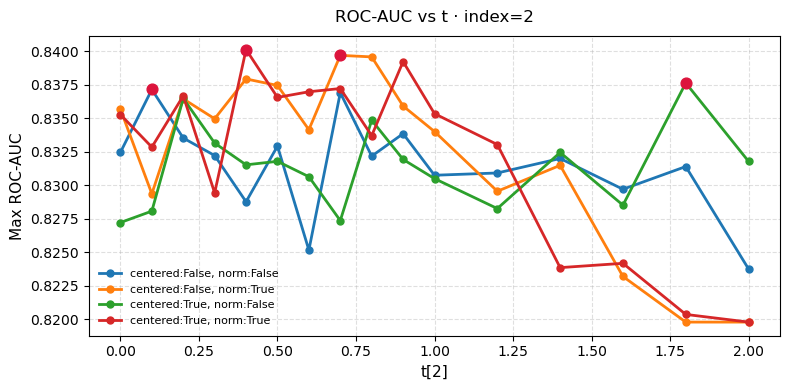

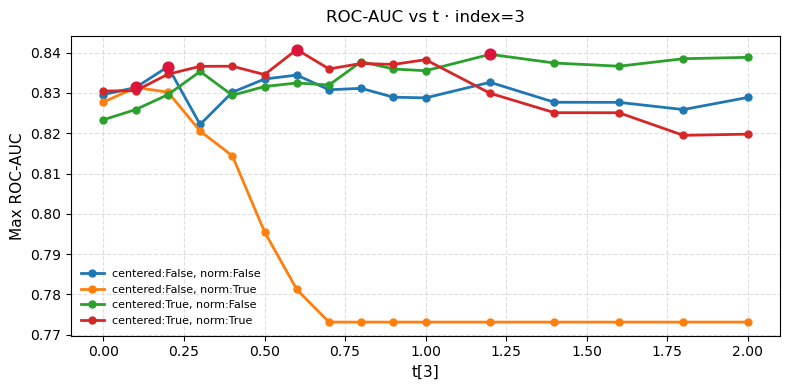

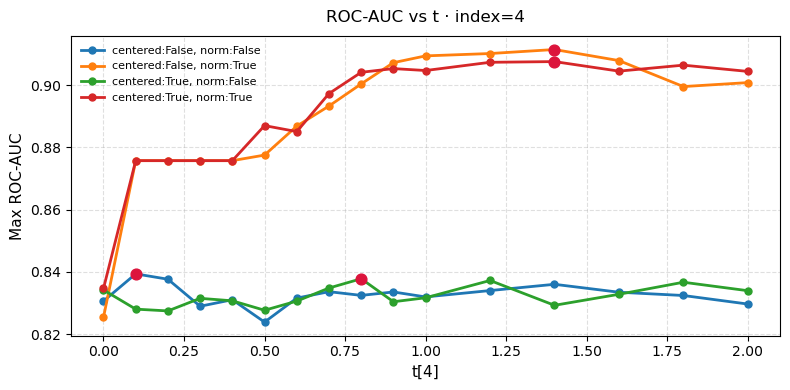

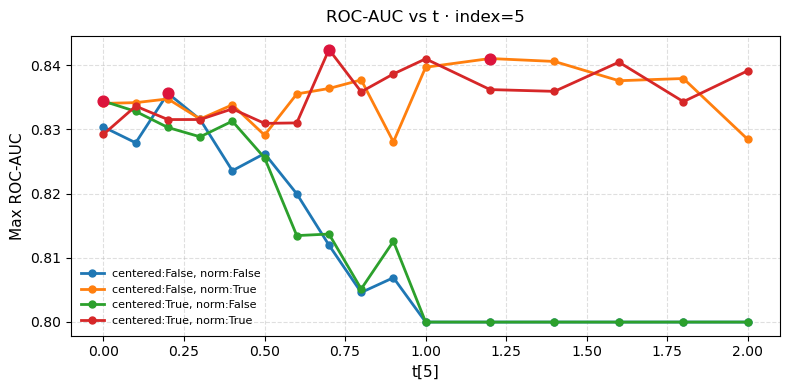

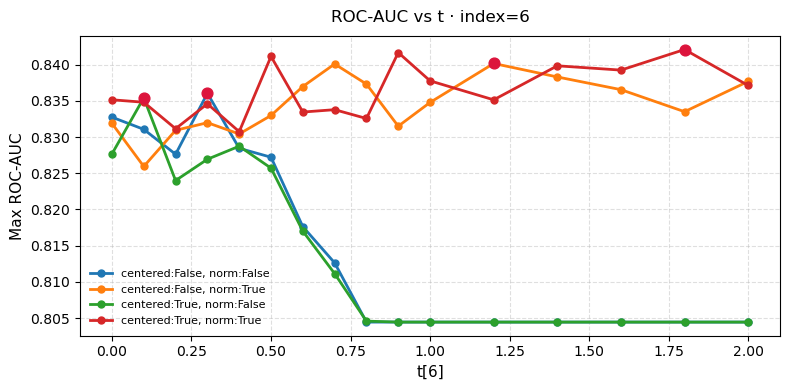

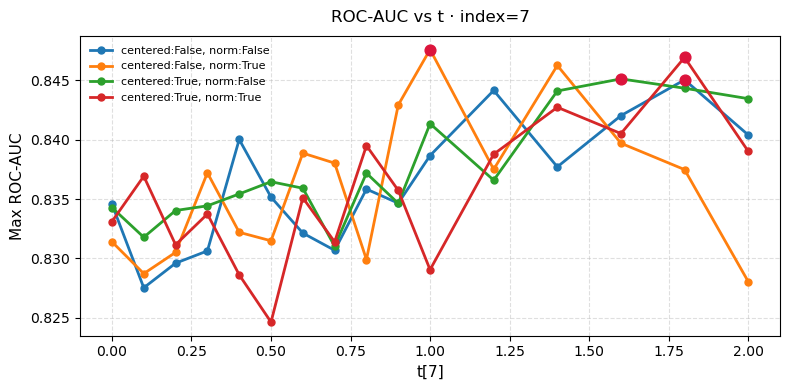

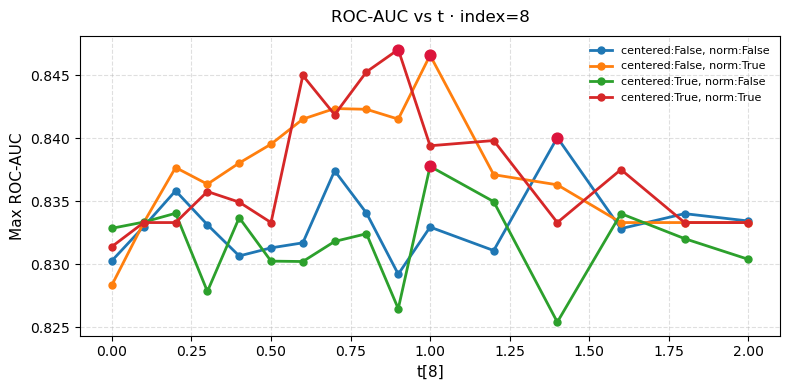

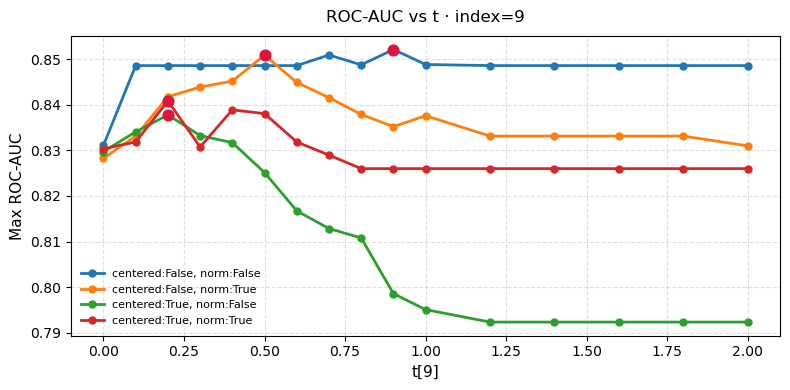

In [15]:
plot_grouped_by_index(results)

In [16]:
for model_name, model_data in results.items():
    print("\n" + "=" * 70)
    print(f"MODEL: {model_name}")
    print("=" * 70)

    for index, index_data in model_data.items():
        print(f"\n  INDEX {index}")
        print("  " + "-" * 60)

        for params, t_data in index_data.items():
            best_auc = -1
            best_record = None

            for v, methods in t_data.items():
                for method_name, (scores, y_test) in methods.items():
                    auc = roc_auc_score(y_test, scores)

                    if auc > best_auc:
                        best_auc = auc
                        best_record = (v, method_name)

            print(f"    {params}")
            print(f"      best ROC-AUC : {best_auc:.4f}")
            print(f"      best t       : {best_record[0]}")
            print(f"      best method  : {best_record[1]}")
            print("      " + "." * 40)


MODEL: sentence-transformers/all-MiniLM-L6-v2

  INDEX 1
  ------------------------------------------------------------
    centered:False, norm:False
      best ROC-AUC : 0.8434
      best t       : 0.4
      best method  : AE
      ........................................
    centered:False, norm:True
      best ROC-AUC : 0.8510
      best t       : 2
      best method  : AE
      ........................................
    centered:True, norm:False
      best ROC-AUC : 0.8376
      best t       : 0.6
      best method  : AE
      ........................................
    centered:True, norm:True
      best ROC-AUC : 0.8471
      best t       : 1.4
      best method  : AE
      ........................................

  INDEX 2
  ------------------------------------------------------------
    centered:False, norm:False
      best ROC-AUC : 0.8372
      best t       : 0.1
      best method  : AE
      ........................................
    centered:False, norm:True
      

## Выводы
